# Logistic Regression (Multiclass — Softmax) 
### Softmax, cross-entropy, one-hot, log-sum-exp stability

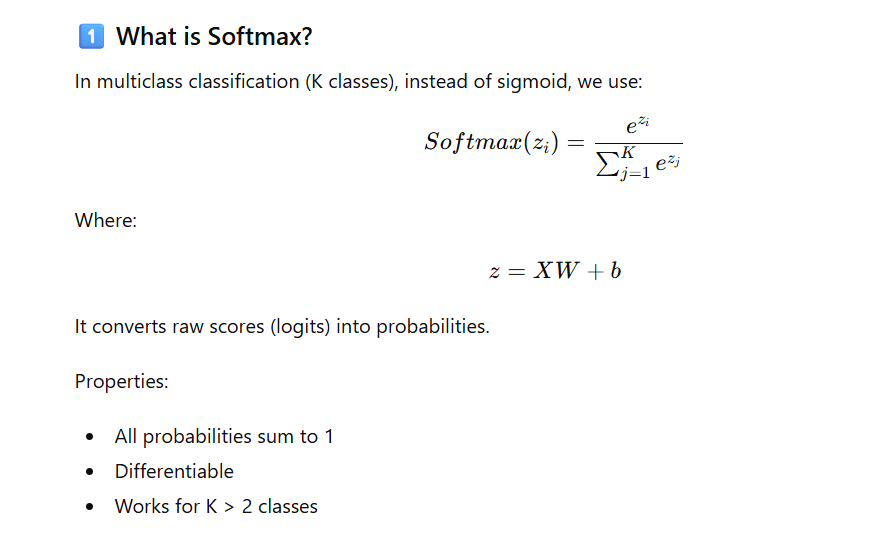

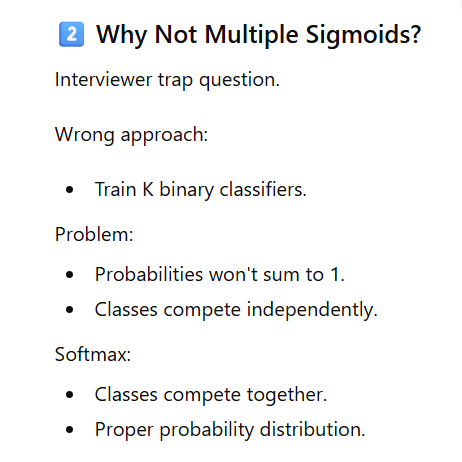

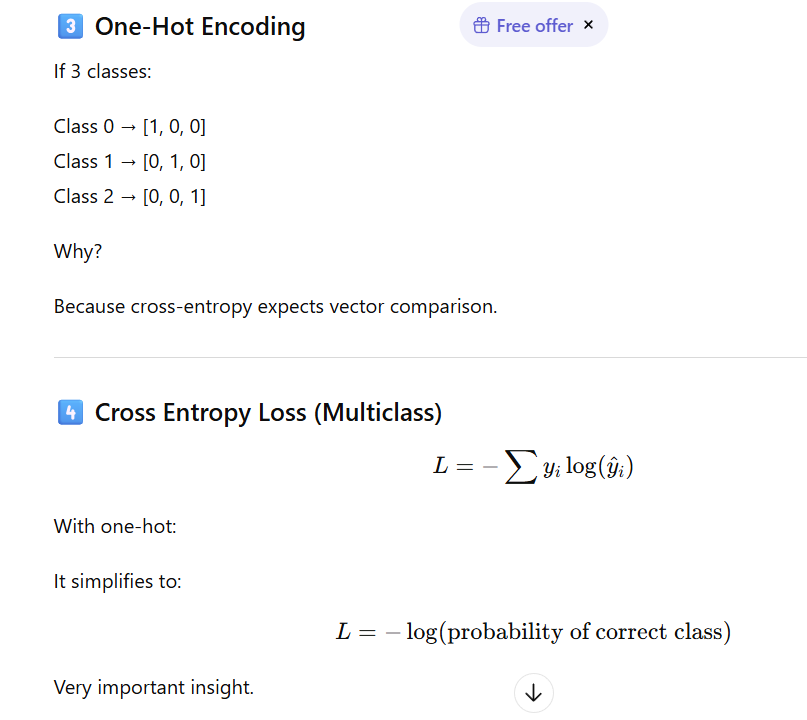

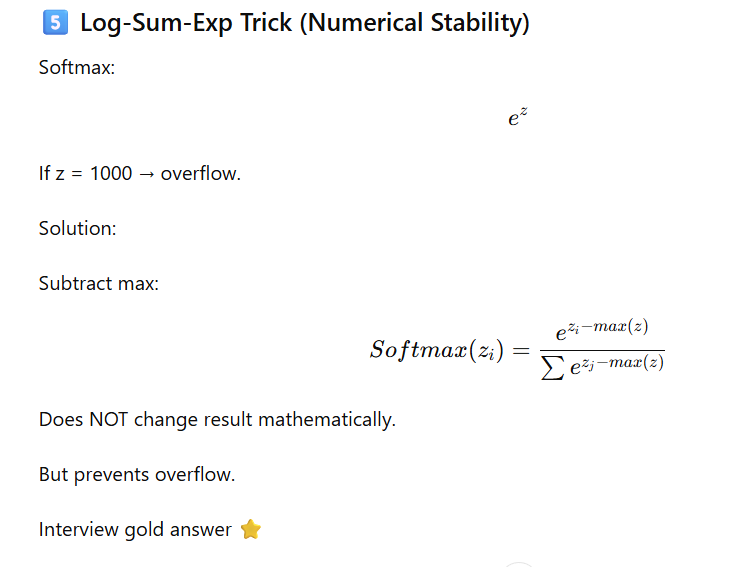

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [9]:
class SoftmaxRegression:

    def __init__(self, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def softmax(self, z):
        z_stable = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_stable)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def one_hot(self, y, num_classes):
        m = y.shape[0]
        one_hot = np.zeros((m, num_classes))
        one_hot[np.arange(m), y] = 1
        return one_hot

    def fit(self, X, y):
        m, n = X.shape
        self.num_classes = len(np.unique(y))

        self.W = np.zeros((n, self.num_classes))
        self.b = np.zeros((1, self.num_classes))

        y_one_hot = self.one_hot(y, self.num_classes)

        for _ in range(self.epochs):
            z = np.dot(X, self.W) + self.b
            y_hat = self.softmax(z)

            dW = (1/m) * np.dot(X.T, (y_hat - y_one_hot))
            db = (1/m) * np.sum(y_hat - y_one_hot, axis=0, keepdims=True)

            self.W -= self.lr * dW
            self.b -= self.lr - db

    def predict(self, X):
        z = np.dot(X, self.W) + self.b
        y_hat = self.softmax(z)
        return np.argmax(y_hat, axis=1)

        

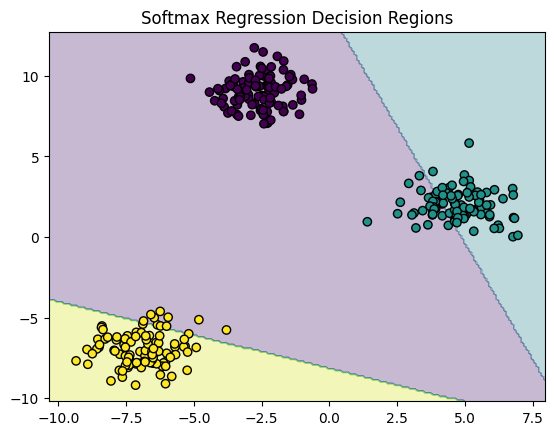

In [10]:
X, y = make_blobs(n_samples=300, centers=3, random_state=42)

model = SoftmaxRegression(lr=0.1, epochs=1000)
model.fit(X,y)

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.title("Softmax Regression Decision Regions")
plt.show()
